# BINARY CLASSIFICATION TASK

The purpose of this code is to train 3 types of machine learning algorithms in classifying diabetics and non-diabetics based on a few medical variables.

Step 1. Import libraries And Data

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
from scipy import stats
import matplotlib.ticker as ticker
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler as MMS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer

Scipy: 1.16.0
Matplotlib: 3.10.5


In [22]:
diabetes_df = pd.read_csv('diabetes.csv')
# https://www.kaggle.com/datasets/lara311/diabetes-dataset-using-many-medical-metrics/data
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2. Visualize, Analyze and Clean Data

In [23]:
# Imbalance analysis
diabetes_df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

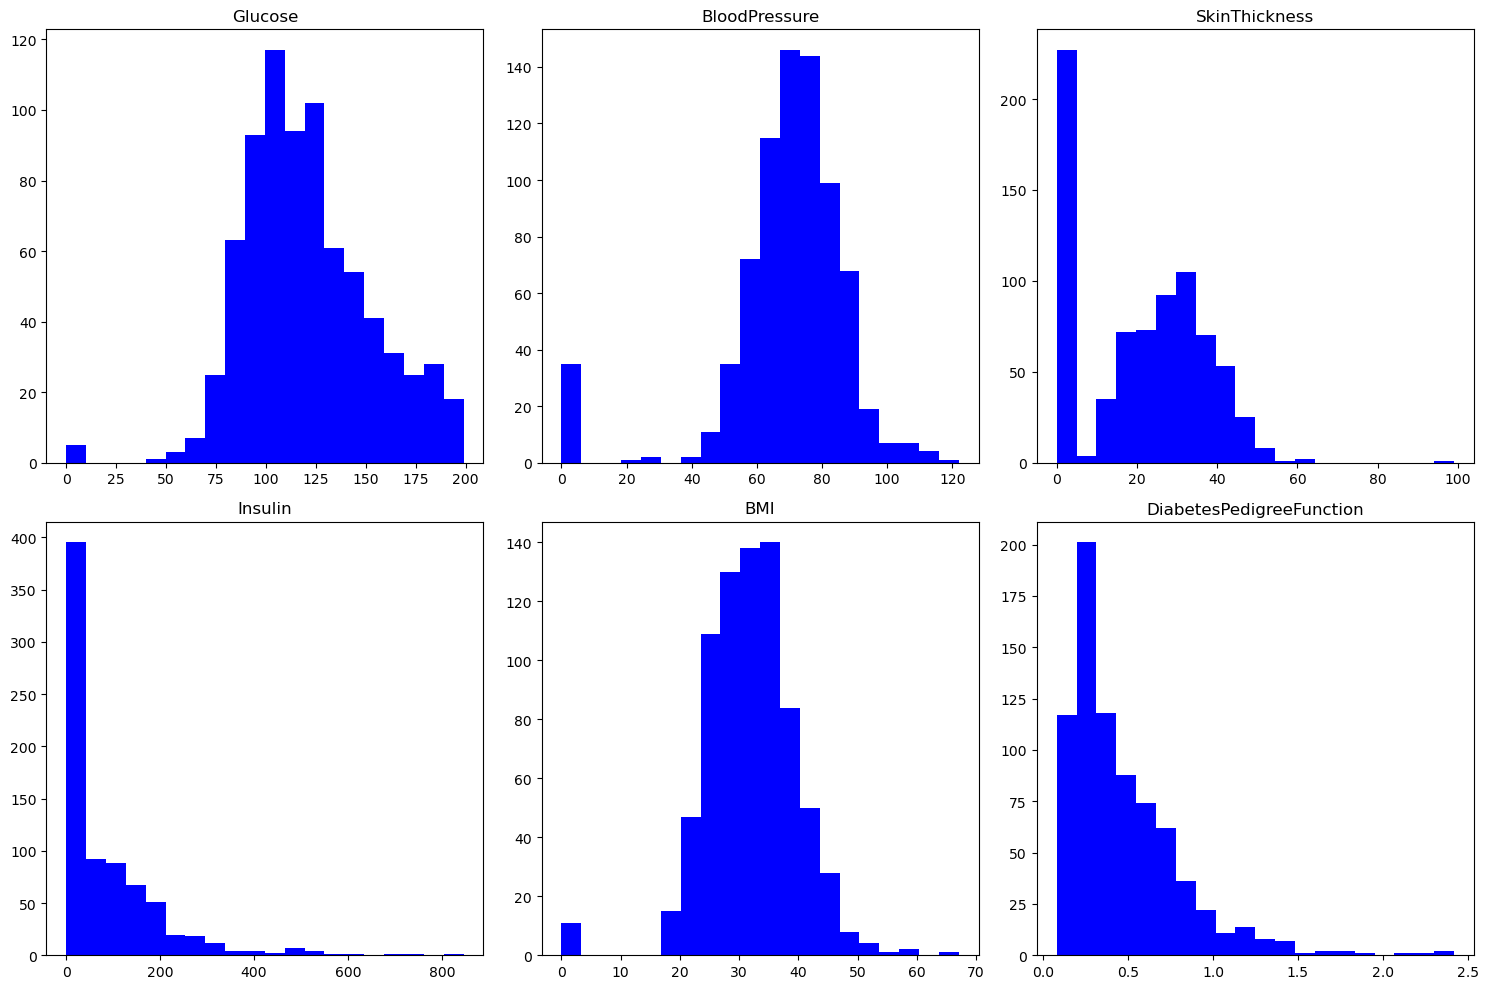

In [24]:
# Visualization of the distribution of values
def show_features_histograms(df):
    features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.flatten()

    for i, feature in enumerate(features):
        axs[i].hist(df[feature], bins=20, facecolor='blue')
        axs[i].set_title(feature)
    
    plt.tight_layout()
    plt.show()

show_features_histograms(diabetes_df)

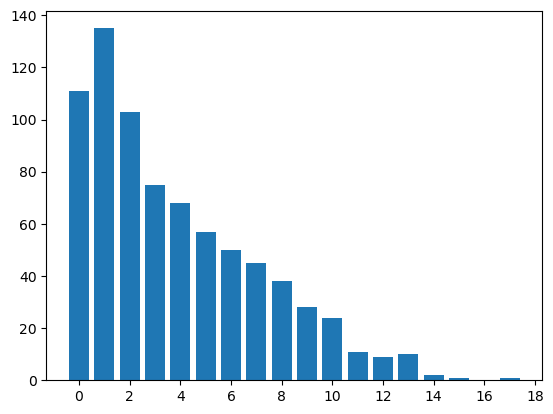

In [25]:
# Distribution of values
def show_feature_bar(df):
    fig = plt.bar(np.sort(df.Pregnancies.unique()), df.Pregnancies.value_counts().sort_index())
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.show()

show_feature_bar(diabetes_df)

According to the graphics, we can see that some variables that should not be able to have zero values, do have zero values. These data points can be considered invalid data and should be removed

In [26]:
def zero_values_report(df):
    report = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            zero_count = (df[col] == 0).sum()
            if zero_count > 0:
                report.append((col, zero_count))
    return pd.DataFrame(report, columns=["Feature", "ZeroCount"]).sort_values(by="ZeroCount", ascending=False)

zero_values_report(diabetes_df)

,Feature,ZeroCount
6,Outcome,500
4,Insulin,374
3,SkinThickness,227
0,Pregnancies,111
2,BloodPressure,35
5,BMI,11
1,Glucose,5


Between the variables that contain zero values, we find the insulin varibable. Because the 0 value in the insulin variable is only possible if the person is diabetic, the zeros are either leading (and thus shouldn't be used in the ml algorithm) or could be placeholders used to indicate that these individuals weren't tested for insulin values. 
Because this information is not shared in the original dataset, a test is required. If zeros in insulin always lead to 1 (diabetic) in the outcome, they are leading, but if not, it means they are just placeholders.

In [27]:
# The insulin variable could be leading (since the value 0 must always come from a diabetic) 
# or could be a placeholder (if there are non-diabetics with a value of 0 in the insulin variable)

def zero_insuline_to_diabetes_percent(df):
    mask = df["Insulin"] == 0

    total_zero_insulin = mask.sum()
    matches = ((df["Insulin"] == 0) & (df["Outcome"] == 1)).sum()
    percentage = (matches / total_zero_insulin) * 100
    
    return print(f"{float(percentage):.2f}%")


zero_insuline_to_diabetes_percent(diabetes_df)

36.90%


Conclusion: zero values in the insulin column are placeholders.

On the next steps, other 0 values will be removed, outliers will be detected and removed, and both missing data and duplicated data will be located and removed.

In [28]:
# Remove invalid data
conditions = (diabetes_df['Glucose'] == 0) | (diabetes_df['BMI'] == 0) | (diabetes_df['BloodPressure'] == 0) | (diabetes_df['SkinThickness'] == 0)
valid_df = diabetes_df[~conditions].copy()

# Converting placehlder from 0 to NaN
valid_df['Insulin'] = valid_df['Insulin'].replace(0, np.nan)

# Delete outliers with IQR method
for feature in ['Glucose', 'BMI', 'DiabetesPedigreeFunction']:
        
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = valid_df[feature].quantile(0.25)
    Q3 = valid_df[feature].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    valid_df = valid_df[(valid_df[feature] >= lower_bound) & (valid_df[feature] <= upper_bound)]

valid_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,NaN,33.6,0.627,50,1
1,1,85,66,29,NaN,26.6,0.351,31,0
3,1,89,66,23,94.0,28.1,0.167,21,0
6,3,78,50,32,88.0,31.0,0.248,26,1
8,2,197,70,45,543.0,30.5,0.158,53,1


In [29]:
valid_df.Outcome.value_counts()

Outcome
0    345
1    161
Name: count, dtype: int64

In [30]:
# Find missing values
findings = list()
for feature in diabetes_df.columns:
    findings.append(f'Total missing values for {feature}: {diabetes_df[feature].isna().sum()}')
print()

# Find duplicated data
findings.append(f'Total duplicated observations: {diabetes_df.duplicated().sum()}')

findings

['Total missing values for Pregnancies: 0',
 'Total missing values for Glucose: 0',
 'Total missing values for BloodPressure: 0',
 'Total missing values for SkinThickness: 0',
 'Total missing values for Insulin: 0',
 'Total missing values for BMI: 0',
 'Total missing values for DiabetesPedigreeFunction: 0',
 'Total missing values for Age: 0',
 'Total missing values for Outcome: 0',
 'Total duplicated observations: 0']

In [31]:
# Use knn to fill the NaN values for insulin
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(valid_df)
valid_df = pd.DataFrame(df_imputed, columns=valid_df.columns)


valid_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,184.6,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.0
2,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
3,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26.0,1.0
4,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0,1.0


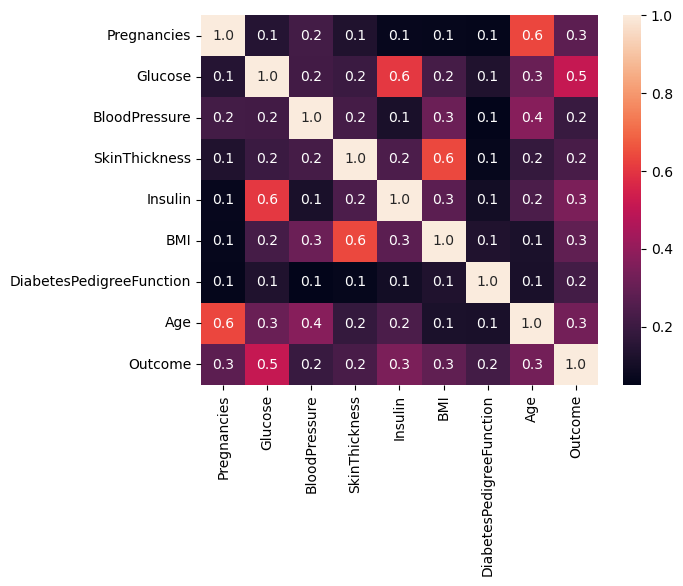

In [32]:
# Visualize correlations
def show_heatmap(df):
    sn.heatmap(data = df.corr(), annot = True, fmt='.1f')
    plt.show()

show_heatmap(valid_df)

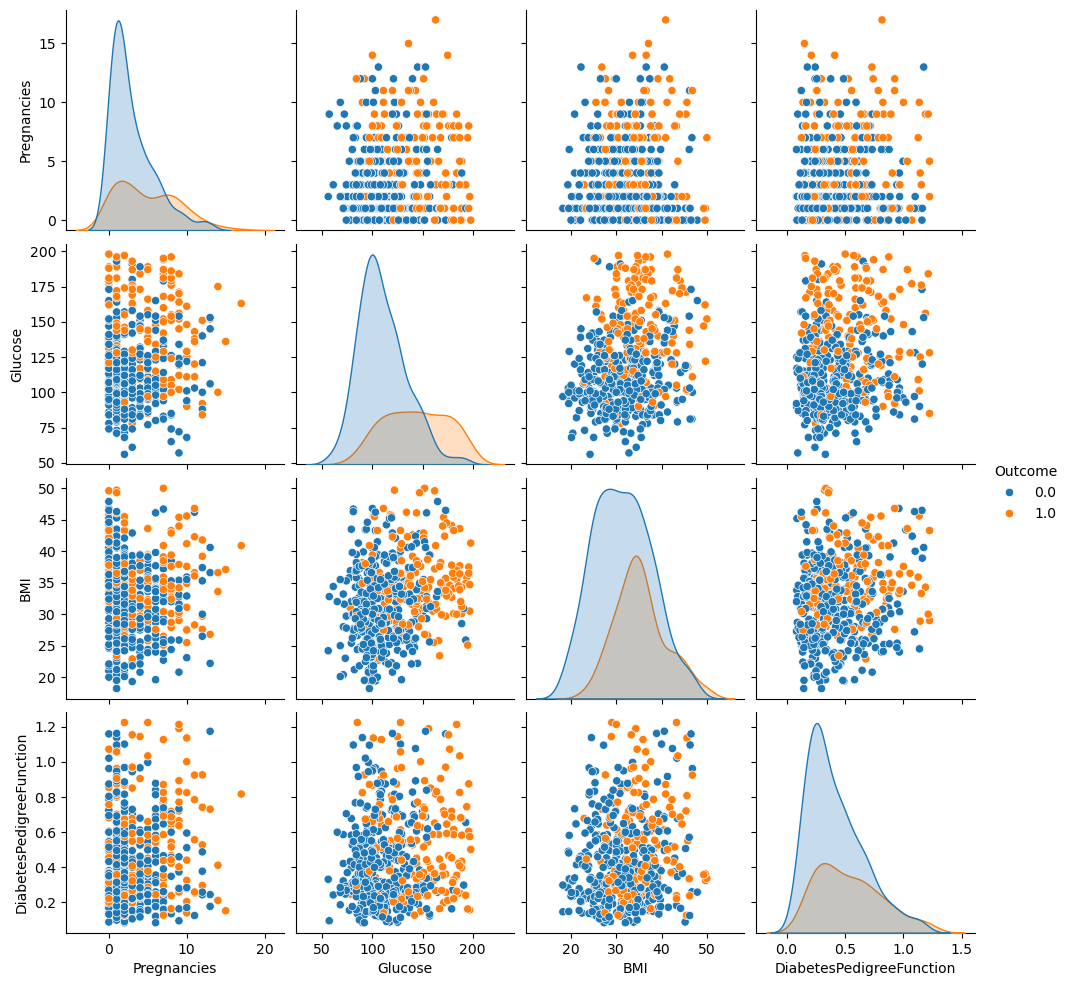

In [33]:
# Visualization of the relationship between pairs of variables
def show_pairplot(df):
    sn.pairplot(df, hue ='Outcome', vars = ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction'])
    plt.show()

show_pairplot(valid_df)

Step 3. Split and Transform Data

In [34]:
# Drop Potential Sources of Noise
valid_df.drop('BloodPressure', axis=1, inplace=True)
valid_df.drop('SkinThickness', axis=1, inplace=True)
valid_df.drop('DiabetesPedigreeFunction', axis=1, inplace=True)

# Split Data
X = valid_df.loc[:, valid_df.columns != 'Outcome']
y = valid_df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Analize if the data follows a normal distribution
features = ['Pregnancies','Glucose', 'BMI', 'Insulin', 'Age']
for feature in features:
    print(f'{feature} kurtosis: {round(stats.kurtosis(valid_df[feature]),4)}')
    print(f'{feature} skew: {round(stats.skew(valid_df[feature]),3)}')
    print()

Pregnancies kurtosis: 0.7243
Pregnancies skew: 1.125

Glucose kurtosis: -0.2978
Glucose skew: 0.615

BMI kurtosis: -0.3108
BMI skew: 0.2

Insulin kurtosis: 7.0193
Insulin skew: 2.14

Age kurtosis: 1.1506
Age skew: 1.257



Pregnancies, Insulin and Age are too skew to be considered normal distribution (acceptable skewness is -0.75 and +075, but it should ideally be between -0.5 and +0.5). 
We will reduce skewness by applying a logaritmic transformation (log1p allows for features with values equal to 0, but can't handle negative data, luckily of the features to be transformed has negatives values) and later standardize the data.

In [36]:
valid_df[["Pregnancies", "Insulin", "Age"]] = valid_df[["Pregnancies", "Insulin", "Age"]].apply(lambda x: np.log1p(x))

# Re-analize if the data follows a normal distribution
features = ['Pregnancies', 'Insulin', 'Age']
for feature in features:
    print(f'{feature} kurtosis: {round(stats.kurtosis(valid_df[feature]),4)}')
    print(f'{feature} skew: {round(stats.skew(valid_df[feature]),3)}')
    print()

Pregnancies kurtosis: -0.9129
Pregnancies skew: -0.074

Insulin kurtosis: 0.2978
Insulin skew: -0.095

Age kurtosis: -0.46
Age skew: 0.734



In [37]:
def transform_data(X_train, X_test):
    scaler = MMS().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)

X_train_scaled, X_test_scaled = transform_data(X_train, X_test)
X_train_scaled

array([[0.05882353, 0.41843972, 0.19565217, 0.56289308, 0.06666667],
       [0.76470588, 0.62411348, 0.11111111, 0.12578616, 0.6       ],
       [0.41176471, 0.26241135, 0.0736715 , 0.47484277, 0.33333333],
       ...,
       [0.        , 0.42553191, 0.20531401, 0.39622642, 0.01666667],
       [0.05882353, 0.39007092, 0.13768116, 0.52201258, 0.05      ],
       [0.41176471, 0.31914894, 0.10507246, 0.59748428, 0.4       ]],
      shape=(404, 5))

Step 4. Train and Compare Models

In [38]:
def train_lr(X80, X20, y80, y20):
    clf = LogisticRegression() 
 
    # Find best parameters for the model
    grid_values = {'C': [0.1, 0.5, 1.0, 10], 'penalty': ['l2']}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    # Test accuracy for train and test (to look for best model and assure no overfitting is happening)
    y20_predicted = best_model.predict(X20)
    y80_predicted = best_model.predict(X80)

    return ((f'train accuracy = {round(accuracy_score(y80, y80_predicted),3)}, test accuracy = {round(accuracy_score(y20, y20_predicted),3)}'))

def train_svm(X80, X20, y80, y20):
    clf = LinearSVC()
    
    # Find best parameters for the model
    grid_values = {'C': [0.1, 0.5, 1.0, 10]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    # Test accuracy for train and test (to look for best model and assure no overfitting is happening)
    y20_predicted = best_model.predict(X20)
    y80_predicted = best_model.predict(X80)

    return (f'train accuracy = {round(accuracy_score(y80, y80_predicted),3)}, test accuracy = {round(accuracy_score(y20, y20_predicted),3)}')

def train_rf(X80, X20, y80, y20):
    clf = RandomForestClassifier()

    # Find best parameters for the model
    grid_values = {'n_estimators': [25, 50, 75, 100], 'max_features': [1, 2, 3], 'max_depth' : [2, 3]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    # Test accuracy for train and test (to look for best model and assure no overfitting is happening)
    y20_predicted = best_model.predict(X20)
    y80_predicted = best_model.predict(X80)

    return (f'train accuracy = {round(accuracy_score(y80, y80_predicted),3)}, test accuracy = {round(accuracy_score(y20, y20_predicted),3)}')

def train_models(X80, X20, y80, y20):
    results = dict()
    results['Logistic_Regression'] = train_lr(X80, X20, y80, y20)
    results['Support Vector Machine'] = train_svm(X80, X20, y80, y20)
    results['Random Forest'] = train_rf(X80, X20, y80, y20)
    return results

# Train different models and return their accuracy to compare their performance
model_scores = train_models(X_train_scaled, X_test_scaled, y_train, y_test)
model_scores

{'Logistic_Regression': 'train accuracy = 0.8, test accuracy = 0.824',
 'Support Vector Machine': 'train accuracy = 0.795, test accuracy = 0.814',
 'Random Forest': 'train accuracy = 0.819, test accuracy = 0.814'}